In [1]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

In [2]:
df = pd.read_csv(r'C:\Project\processed datasets\EV_usage_for_ML.csv')

In [3]:
df.head()

,vehicle_type,battery_capacity_kwh,battery_health_pct,distance_km,daily_trip_count,charging_frequency_per_week,charging_type,charging_station_distance_km,energy_consumed_kwh,electricity_cost_per_kwh,weather_condition,traffic_density,user_income_level,range_km_estimated,user_income_level.1,range_anxiety_risk,effective_battery_capacity
0,2W,3.59,83.51,37.52,1.0,4.00,public_fast,1.36,5.50,7.92,clear,0.331,middle,21.54,middle,0.0,2.998
1,2W,3.44,87.33,10.61,3.0,6.00,public_slow,1.39,1.49,8.40,humid,0.285,low,20.62,low,0.0,3.004
2,2W,3.14,98.67,34.88,3.0,4.00,home,0.17,7.06,5.70,extreme_heat,0.120,low,16.03,low,0.0,3.098
3,2W,2.06,88.74,1.00,2.0,1.00,public_fast,0.55,0.12,8.29,rainy,0.331,middle,11.10,middle,0.0,1.828
4,2W,2.64,86.47,61.73,2.0,3.33,public_fast,2.67,3.19,9.28,extreme_heat,0.068,middle,13.47,middle,1.0,2.283


In [4]:
df = df[df['range_anxiety_risk'] != 0.19]

In [5]:
df = df.drop(columns = ['user_income_level.1'] )

In [6]:
oe  = OrdinalEncoder()

In [7]:
df.columns

Index(['vehicle_type', 'battery_capacity_kwh', 'battery_health_pct',
       'distance_km', 'daily_trip_count', 'charging_frequency_per_week',
       'charging_type', 'charging_station_distance_km', 'energy_consumed_kwh',
       'electricity_cost_per_kwh', 'weather_condition', 'traffic_density',
       'user_income_level', 'range_km_estimated', 'range_anxiety_risk',
       'effective_battery_capacity'],
      dtype='str')

In [8]:
df["range_anxiety_risk"] = df["range_anxiety_risk"].map({
    0.00: 0,    # Low risk
    1.00: 1     # High risk
})

In [9]:
df["range_anxiety_risk"].value_counts().sort_index()

range_anxiety_risk
0    7761
1    2449
Name: count, dtype: int64

In [10]:
df.dtypes

vehicle_type                        str
battery_capacity_kwh            float64
battery_health_pct              float64
distance_km                     float64
daily_trip_count                float64
charging_frequency_per_week     float64
charging_type                       str
charging_station_distance_km    float64
energy_consumed_kwh             float64
electricity_cost_per_kwh        float64
weather_condition                   str
traffic_density                 float64
user_income_level                   str
range_km_estimated              float64
range_anxiety_risk                int64
effective_battery_capacity      float64
dtype: object

In [11]:
df[['vehicle_type','charging_type','weather_condition','user_income_level']] = oe.fit_transform(df[['vehicle_type','charging_type','weather_condition','user_income_level']])

In [12]:
df.dtypes

vehicle_type                    float64
battery_capacity_kwh            float64
battery_health_pct              float64
distance_km                     float64
daily_trip_count                float64
charging_frequency_per_week     float64
charging_type                   float64
charging_station_distance_km    float64
energy_consumed_kwh             float64
electricity_cost_per_kwh        float64
weather_condition               float64
traffic_density                 float64
user_income_level               float64
range_km_estimated              float64
range_anxiety_risk                int64
effective_battery_capacity      float64
dtype: object

In [13]:
x = df[['vehicle_type', 'battery_capacity_kwh', 'battery_health_pct',
       'distance_km', 'daily_trip_count', 'charging_frequency_per_week',
       'charging_type', 'charging_station_distance_km', 'energy_consumed_kwh',
       'electricity_cost_per_kwh', 'weather_condition', 'traffic_density',
       'user_income_level', 'range_km_estimated','effective_battery_capacity']]
y = df['range_anxiety_risk']

### Decision Tree Classifier

In [14]:
from sklearn.tree import DecisionTreeClassifier

In [15]:
corr = df.corr()

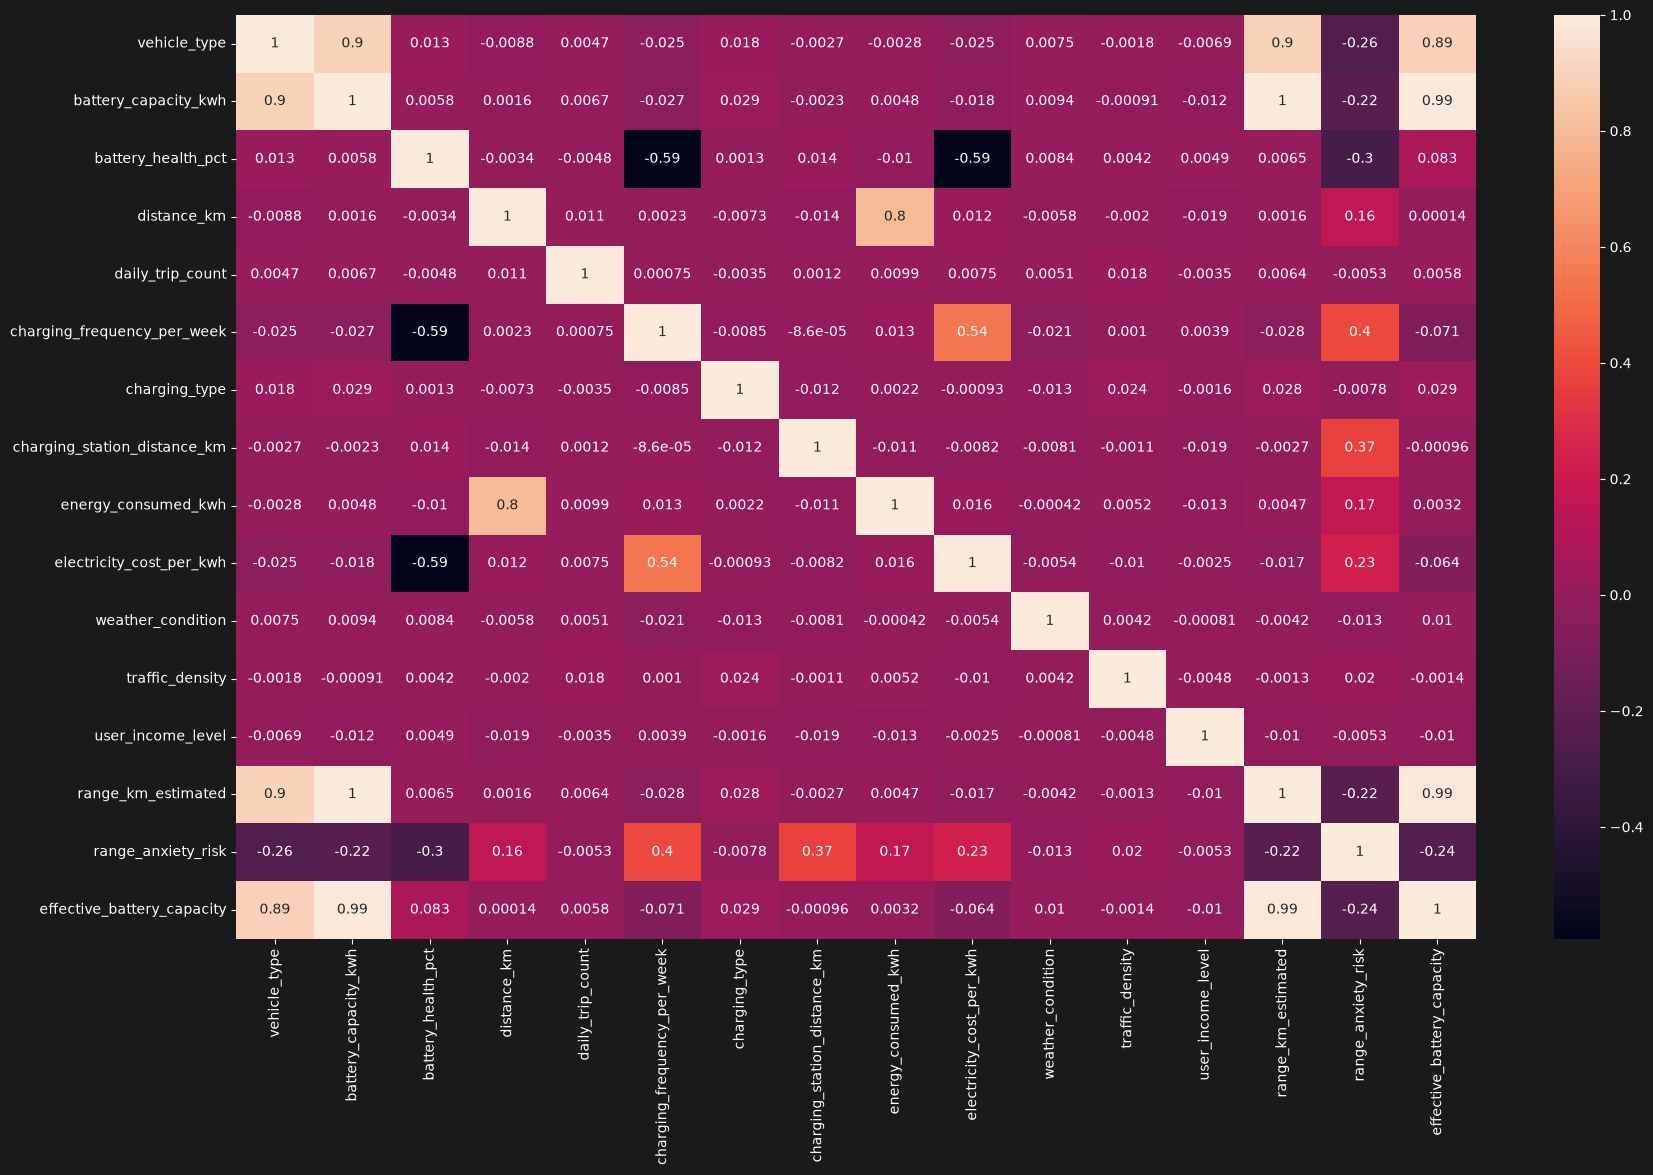

In [16]:
plt.figure(figsize = (20,12))
sns.heatmap(corr, annot = True)
plt.show()

In [17]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [18]:
model = DecisionTreeClassifier(random_state = 42, class_weight = 'balanced')

In [19]:
model.fit(x_train,y_train) 

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_f

In [20]:
y_pred = model.predict (x_test)

In [21]:
acc = accuracy_score(y_test, y_pred)
print('the accuracy score of given model is:',round((acc*100),3),'%')

the accuracy score of given model is: 95.544 %


In [22]:
confusion = confusion_matrix(y_test, y_pred)
print(confusion)

[[1479   39]
 [  52  472]]


In [23]:
cls_rep = classification_report(y_test, y_pred)
print(cls_rep)

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1518
           1       0.92      0.90      0.91       524

    accuracy                           0.96      2042
   macro avg       0.94      0.94      0.94      2042
weighted avg       0.96      0.96      0.96      2042



### Random Forest classifier

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_validate

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

r_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_weighted',
    'recall': 'recall_weighted',
    'f1': 'f1_weighted'
}

res = cross_validate(model, x_train, y_train, cv=kfold, scoring=scoring )

print("Accuracy :", res['test_accuracy'].mean())
print("Precision:", res['test_precision'].mean())
print("Recall   :", res['test_recall'].mean())
print("F1 Score :", res['test_f1'].mean())

Accuracy : 0.9604535663714691
Precision: 0.9605856246851617
Recall   : 0.9604535663714691
F1 Score : 0.9604474881061537


In [25]:
r_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [26]:
y_predict = r_model.predict(x_test)

In [27]:
acc = accuracy_score(y_test, y_predict)
print('the accuracy score of given model is:',round((acc*100),3),'%')

the accuracy score of given model is: 97.16 %


In [28]:
cm = confusion_matrix(y_test, y_predict)
cm

array([[1498,   20],
       [  38,  486]])

In [29]:
rep = classification_report(y_test, y_predict)
print(rep)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1518
           1       0.96      0.93      0.94       524

    accuracy                           0.97      2042
   macro avg       0.97      0.96      0.96      2042
weighted avg       0.97      0.97      0.97      2042



### Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
logReg = LogisticRegression(max_iter = 1000)

In [32]:
logReg.fit(x_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [33]:
y_pred_lr = logReg.predict(x_test)

In [34]:
acc = accuracy_score(y_test, y_pred_lr)
print('the accuracy score of given model is:',round((acc*100),3),'%')

the accuracy score of given model is: 86.582 %


In [35]:
cm = confusion_matrix(y_test, y_pred_lr)
cm

array([[1434,   84],
       [ 190,  334]])

In [36]:
rep = classification_report(y_test, y_pred_lr)
print(rep)

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1518
           1       0.80      0.64      0.71       524

    accuracy                           0.87      2042
   macro avg       0.84      0.79      0.81      2042
weighted avg       0.86      0.87      0.86      2042



### XGBoost

In [37]:
!pip install xgboost


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

In [39]:
xgb.fit(x_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [40]:
xgb_pred = xgb.predict(x_test)

In [41]:
acc = accuracy_score(y_test, xgb_pred)
print('the accuracy score of given model is:',round((acc*100),3),'%')

the accuracy score of given model is: 97.258 %


In [42]:
cm = confusion_matrix(y_test, xgb_pred)
cm

array([[1490,   28],
       [  28,  496]])

In [43]:
rep = classification_report(y_test, xgb_pred)
print(rep)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1518
           1       0.95      0.95      0.95       524

    accuracy                           0.97      2042
   macro avg       0.96      0.96      0.96      2042
weighted avg       0.97      0.97      0.97      2042



In [46]:
fh = open(r'C:\Project\EV station website\pickle files\anxiety.pkl', 'wb')
pickle.dump(xgb, fh)
fh.close()